# Module 4: Deep Learning — Brain Tumor Segmentation
**Course**: Computer Vision | Christian Mata, PhD

**Dataset**: LGG Brain MRI Segmentation (Kaggle — mateuszbuda)

**Task**: Pixel-wise binary segmentation — which pixels belong to the tumor?

**Group members**: Martin Caro, Edison Zyberaj


## 1. Install dependencies

In [1]:
!pip install git+https://github.com/tensorflow/examples.git
!pip install -U keras
!pip install -q tensorflow_datasets
!pip install -q -U tensorflow-text tensorflow

  Cloning https://github.com/tensorflow/examples.git to /tmp/pip-req-build-zjl35__b
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/examples.git /tmp/pip-req-build-zjl35__b
  Resolved https://github.com/tensorflow/examples.git to commit 7d64849545cd682230dce48b8cc8bc375d95d1e8
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-examples: filename=tensorflow_examples-0.1779265295.715865470489431931060322430528026120936890946024-py3-none-any.whl size=300309 sha256=3f6686e2734f937d7c251b9831d6f8da9bbd3b023efb395492f8424df75bb61e
  Stored in directory: /tmp/pip-ephem-wheel-cache-6s_qtuaq/wheels/ab/17/30/d16d07e2c95286770a9ddcd6f41629ea92b998858c5ee235aa
Successfully built tensorflow-examples
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.0 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2


## 2. Kaggle setup — upload kaggle.json when prompted

In [2]:
!pip install -q kaggle
from google.colab import files
print('Upload your kaggle.json API key:')
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle configured ✓')

Upload your kaggle.json API key:


Saving kaggle.json to kaggle.json
Kaggle configured ✓


## 3. Download, extract, and convert to PNG

In [3]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q lgg-mri-segmentation.zip -d brain/
print('Download and extraction complete ✓')

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:38<00:00, 19.4MB/s]

Download and extraction complete ✓


In [4]:
import os, glob
import numpy as np
from PIL import Image

IMG_SIZE   = 128
all_tif    = sorted(glob.glob('brain/kaggle_3m/**/*.tif', recursive=True))
image_tifs = [p for p in all_tif if '_mask' not in p]
mask_tifs  = [p.replace('.tif', '_mask.tif') for p in image_tifs]

os.makedirs('brain/images', exist_ok=True)
os.makedirs('brain/masks',  exist_ok=True)

image_pngs = []
mask_pngs  = []

for img_tif, msk_tif in zip(image_tifs, mask_tifs):
    img_png = 'brain/images/' + os.path.basename(img_tif).replace('.tif', '.png')
    msk_png = 'brain/masks/'  + os.path.basename(msk_tif).replace('.tif', '.png')

    Image.open(img_tif).resize((IMG_SIZE, IMG_SIZE)).save(img_png)
    mask_arr = np.array(Image.open(msk_tif).convert('L'))
    Image.fromarray(mask_arr).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST).save(msk_png)

    image_pngs.append(img_png)
    mask_pngs.append(msk_png)

print(f'Converted {len(image_pngs)} image-mask pairs to PNG ✓')

Converted 3929 image-mask pairs to PNG ✓


## 4. Imports

In [5]:
import numpy as np

import tensorflow as tf
import tensorflow_datasets as tfds

In [6]:
from tensorflow_examples.models.pix2pix import pix2pix

from IPython.display import clear_output
import matplotlib.pyplot as plt

## 5. Preprocessing — normalize and load_image

In [7]:
def normalize(input_image, input_mask):
  # image already float32 in [0, 1]; mask already binary int32 {0, 1}
  return input_image, input_mask

In [8]:
def load_image(image_path, mask_path):
  # Load brain MRI slice (PNG, 3-channel)
  image = tf.io.read_file(image_path)
  image = tf.image.decode_png(image, channels=3)
  image = tf.image.resize(image, (128, 128))

  # Load binary tumor mask (PNG, grayscale)
  raw_mask = tf.io.read_file(mask_path)
  mask     = tf.image.decode_png(raw_mask, channels=1)
  mask     = tf.image.resize(mask, (128, 128),
                             method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

  input_image, input_mask = normalize(
      tf.cast(image, tf.float32) / 255.0,
      tf.cast(mask > 127, tf.int32)
  )
  return input_image, input_mask

In [11]:
# Train / validation split
N_TRAIN = 3000
N_VAL   = len(image_pngs) - N_TRAIN

train_img = image_pngs[:N_TRAIN]
train_msk = mask_pngs[:N_TRAIN]
val_img   = image_pngs[N_TRAIN:]
val_msk   = mask_pngs[N_TRAIN:]

TRAIN_LENGTH    = len(train_img)
BATCH_SIZE      = 32
BUFFER_SIZE     = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

print('Training samples:  ', TRAIN_LENGTH)
print('Validation samples:', N_VAL)
print('Batch size:        ', BATCH_SIZE)
print('Steps per epoch:   ', STEPS_PER_EPOCH)

Training samples:   3000
Validation samples: 929
Batch size:         32
Steps per epoch:    93


In [12]:
train_images = tf.data.Dataset.from_tensor_slices((train_img, train_msk)).map(
    load_image, num_parallel_calls=tf.data.AUTOTUNE)

test_images = tf.data.Dataset.from_tensor_slices((val_img, val_msk)).map(
    load_image, num_parallel_calls=tf.data.AUTOTUNE)

In [13]:
class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    # both use the same seed, so they'll make the same random changes.
    self.augment_inputs = tf.keras.layers.RandomFlip(mode='horizontal', seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode='horizontal', seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels

In [14]:
train_batches = (
    train_images
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))

test_batches = test_images.batch(BATCH_SIZE)

## 6. Visualize a sample image and its tumor mask

In [18]:
def display(display_list):
  plt.figure(figsize=(15, 15))

  title = ['Input Image', 'True Mask', 'Predicted Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

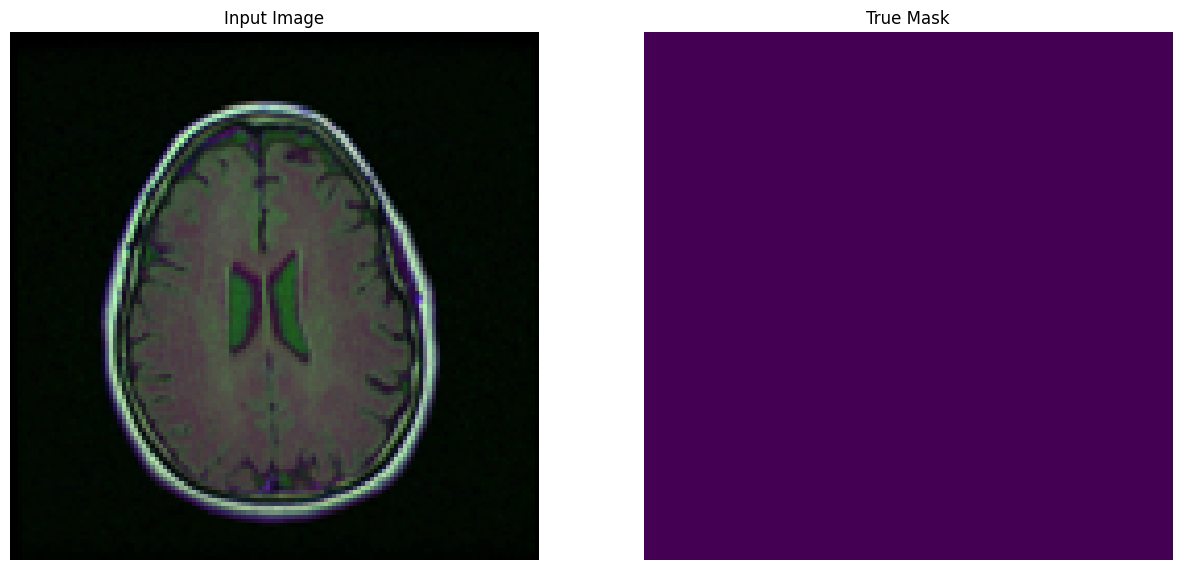

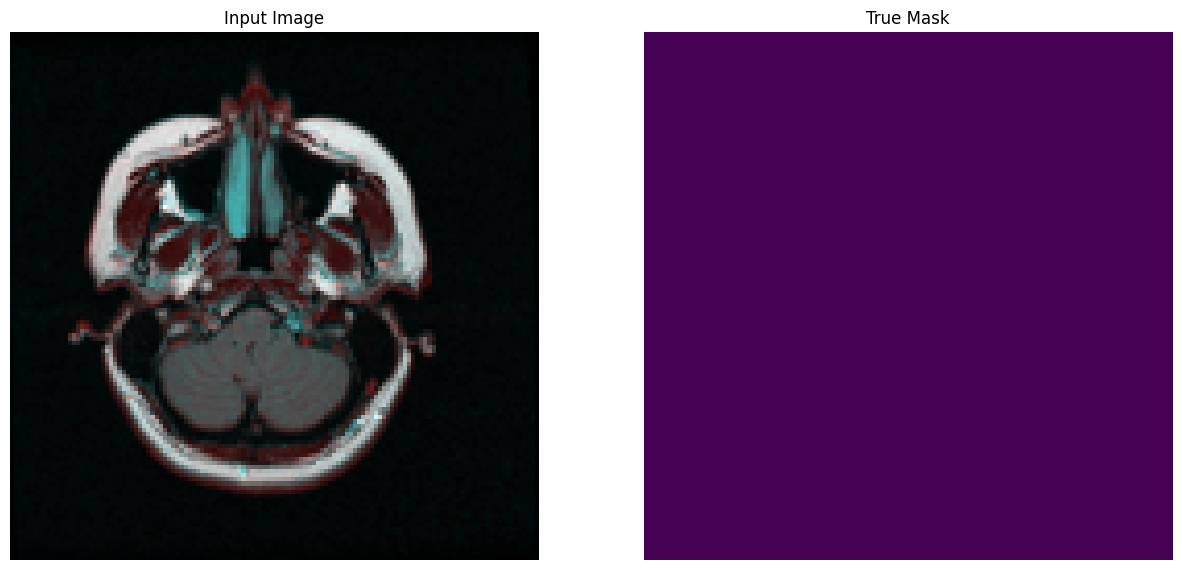

In [19]:
for images, masks in train_batches.take(2):
  sample_image, sample_mask = images[0], masks[0]
  display([sample_image, sample_mask])

## 7. Define the U-Net model

In [20]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

# Use the activations of these layers
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)

down_stack.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [21]:
up_stack = [
    pix2pix.upsample(512, 3),  # 4x4 -> 8x8
    pix2pix.upsample(256, 3),  # 8x8 -> 16x16
    pix2pix.upsample(128, 3),  # 16x16 -> 32x32
    pix2pix.upsample(64, 3),   # 32x32 -> 64x64
]

In [22]:
def unet_model(output_channels:int):
  inputs = tf.keras.layers.Input(shape=[128, 128, 3])

  # Downsampling through the model
  skips = down_stack(inputs)
  x = skips[-1]
  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    concat = tf.keras.layers.Concatenate()
    x = concat([x, skip])

  # This is the last layer of the model
  last = tf.keras.layers.Conv2DTranspose(
      filters=output_channels, kernel_size=3, strides=2,
      padding='same')  #64x64 -> 128x128

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

## 8. Compile the model

In [23]:
# Binary segmentation: tumor pixels (1) vs background (0)
OUTPUT_CLASSES = 2

model = unet_model(output_channels=OUTPUT_CLASSES)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

## 9. Prediction before training (baseline)

In [25]:
def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

In [26]:
def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(model.predict(sample_image[tf.newaxis, ...]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step


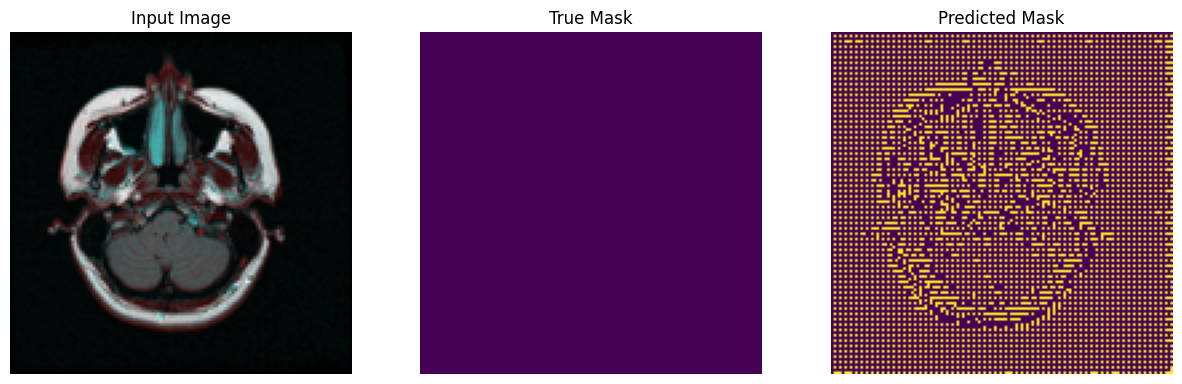

In [27]:
show_predictions()

## 10. Train the model

In [28]:
class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


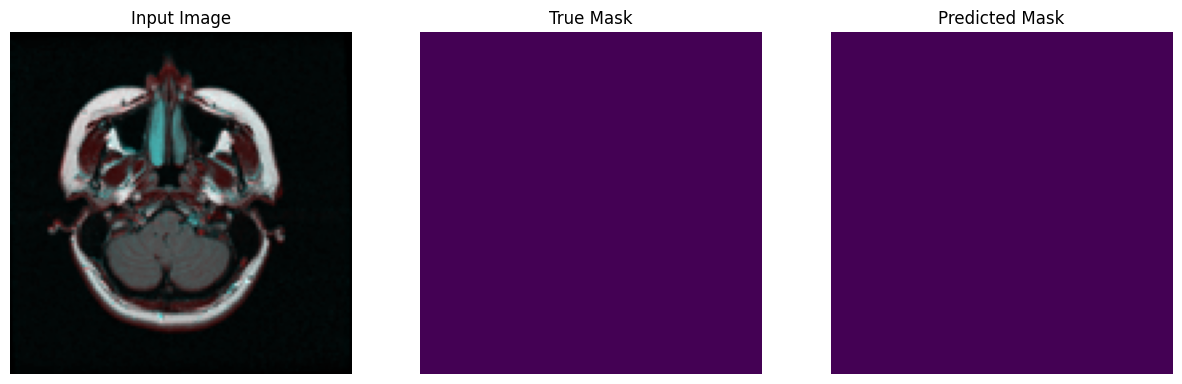


Sample Prediction after epoch 20

93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9976 - loss: 0.0063 - val_accuracy: 0.9950 - val_loss: 0.0157


In [29]:
EPOCHS = 20
VAL_SUBSPLITS = 5
VALIDATION_STEPS = max(1, len(val_img) // BATCH_SIZE // VAL_SUBSPLITS)

model_history = model.fit(train_batches, epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=test_batches,
                          callbacks=[DisplayCallback()])

## 11. Training and Validation Loss

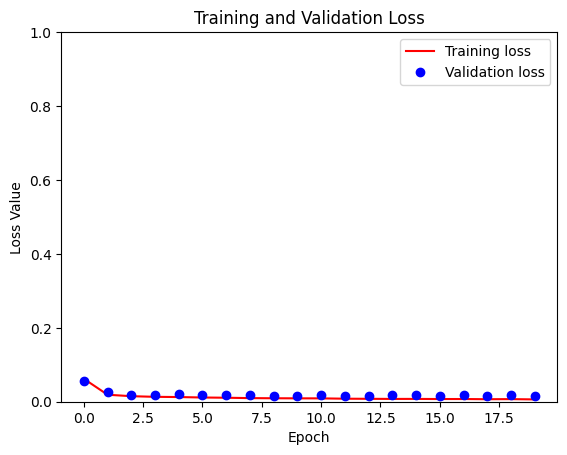

In [31]:
loss     = model_history.history['loss']
val_loss = model_history.history['val_loss']

plt.figure()
plt.plot(model_history.epoch, loss, 'r', label='Training loss')
plt.plot(model_history.epoch, val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.ylim([0, 1])
plt.legend()
plt.show()

## 12. Predictions on the validation set

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


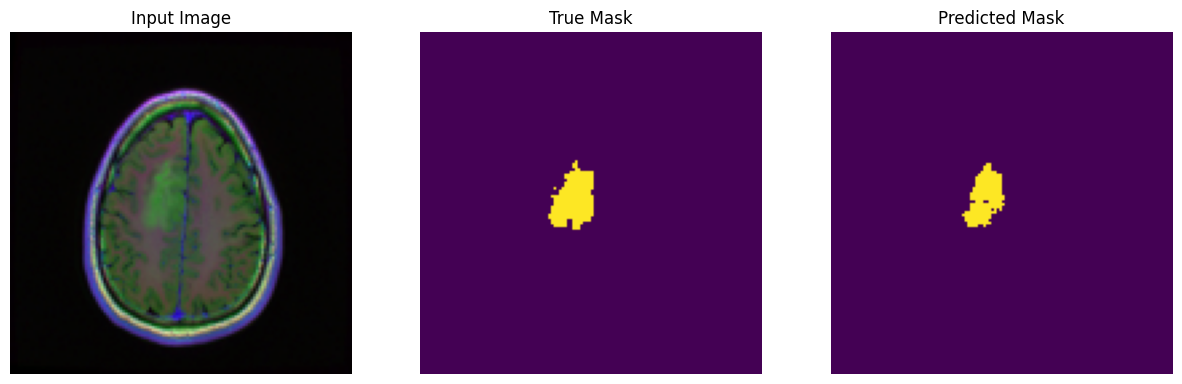

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


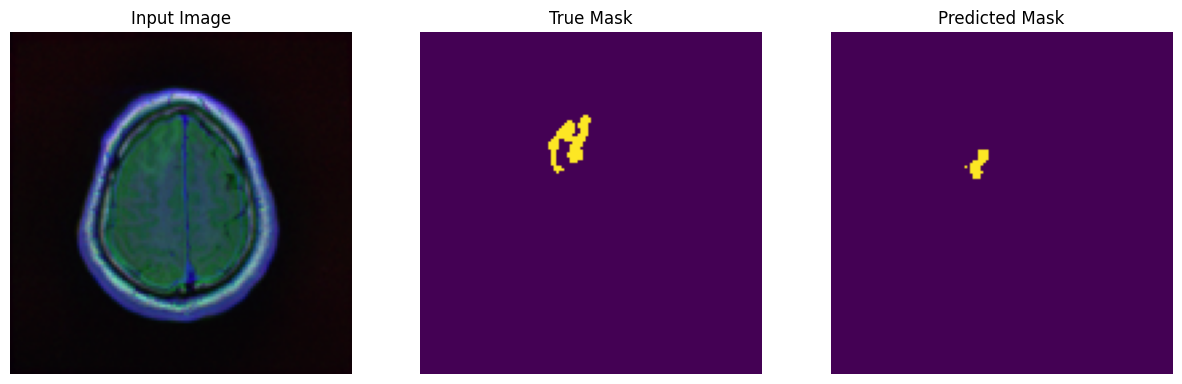

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


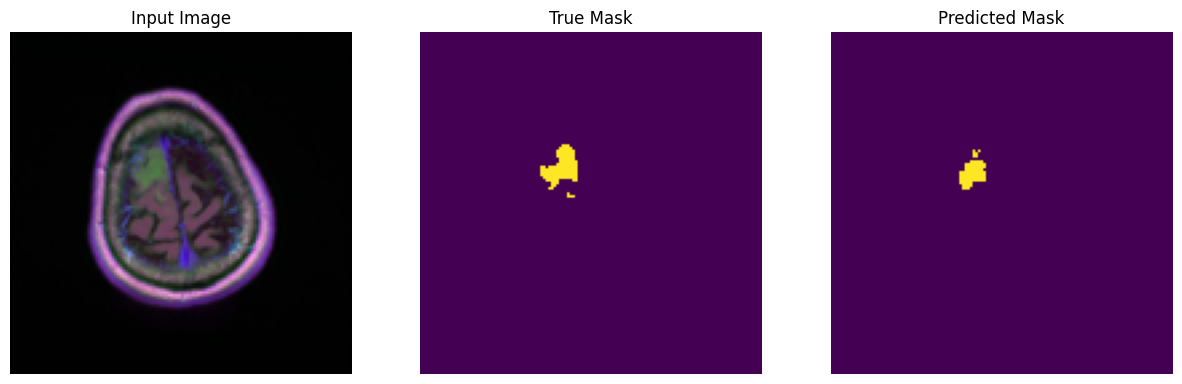

In [32]:
show_predictions(test_batches, 3)

## 13. Class weights — handling severe pixel imbalance

In [33]:
# In brain tumor MRI, the tumor occupies a tiny fraction of the total pixels.
# The background class (0) dominates. We heavily upweight the tumor class (1)
# so the loss penalises missed tumor pixels much more than missed background pixels.

def add_sample_weights(image, label):
  # The weights for each class, with the constraint that:
  #     sum(class_weights) == 1.0
  class_weights = tf.constant([1.0, 5.0])  # strongly upweight tumor pixels (class 1)
  class_weights = class_weights/tf.reduce_sum(class_weights)

  # Create an image of sample_weights by using the label at each pixel as an
  # index into the class_weights.
  sample_weights = tf.gather(class_weights, indices=tf.cast(label, tf.int32))

  return image, label, sample_weights

In [34]:
train_batches.map(add_sample_weights).element_spec

(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None))

In [35]:
weighted_model = unet_model(OUTPUT_CLASSES)
weighted_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

weighted_model.fit(
    train_batches.map(add_sample_weights),
    epochs=1,
    steps_per_epoch=10)

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.9871 - loss: 0.0256


## 14. Discussion

**Dataset.** The same LGG Brain MRI dataset is used here for a different task: instead of classifying the whole slice, we predict a pixel-wise binary mask indicating which pixels belong to the tumor. This demonstrates that the same data can support both classification and segmentation — two fundamentally different problem formulations.

**Model.** This model implements the U-Net architechture. The pretrained MobileNetV2 encoder (frozen ImageNet weights) serves as the downsampling path, extracting features at progressively smaller spatial scales. The pix2pix decoder upsamples back to the original resolution using skip connections that preserve fine spatial detail from the encoder.

**Class imbalance.** This is more severe than any dataset in the course: tumor pixels can be less than 1% of all pixels in a slice. A naive model that predicts 'background' everywhere achieves 99%+ pixel accuracy but is clinically useless. This is addressed by multiplying the loss for tumor pixels by 5×, forcing the model to prioritise correctly detecting the small tumor region.

